## Data Exploration Notebook for IFood Data Science Technical Case

## 1. Import Libraries

In [1]:
import numpy as np
from itertools import chain
from collections import Counter
import matplotlib.pyplot as plt

from pyspark.sql.functions import col, sum, when, count, to_date, year, avg, from_json, coalesce, corr,create_map, lit, dense_rank
from pyspark.sql import Window as W
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder

# Cria a sessão Spark local
spark = SparkSession.builder.appName("ifoodProcessingData").master("local[*]").getOrCreate()

# Verifica
print(spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/09/27 16:57:09 WARN Utils: Your hostname, marianna-pinho, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/09/27 16:57:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/27 16:57:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/09/27 16:57:20 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


4.0.1


## 2. Utilities

In [2]:
def get_columns_with_nulls(dataframe):
    return dataframe.select([sum(col(c).isNull().cast("int")).alias(c) for c in dataframe.columns])

def info_alternative(dataframe):
    n_rows = dataframe.count()
    print(f"Number of rows: {n_rows}")
    print(f"Number of columns: {len(dataframe.columns)}")
    number_of_nans_in_cols = get_columns_with_nulls(dataframe)
    print("#\tColumn\t\tNon-Null Count\t\tDtype")
    print("---\t------\t\t--------------\t\t-----")
    for index, (col, col_type) in enumerate(dataframe.dtypes):
        print(f"{index}\t{col}\t\t{n_rows - number_of_nans_in_cols.first()[col]}\t\t{col_type}")


def create_id_int_column(data, column_map, original_column_name, new_column_name):
    mapping_expr = create_map([lit(x) for x in chain(*column_map.items())])

    return data.withColumn(
        new_column_name,
        coalesce(
            mapping_expr[col(original_column_name)],
            lit(-1)   # default se não achar a chave
            )
        )

In [3]:
def plot_bars(axes, data_values, data_labels, data_colors, title, x_label, y_label):
    axes.bar(x=data_labels, height=data_values, color=data_colors)
    axes.set_title(title)
    axes.set_xlabel(x_label)
    axes.set_ylabel(y_label)

    return axes

def plot_hist(axes, data_values, n_bins, title, x_label, y_label, data_mean=None, data_median=None, mean_color="tab:red", median_color="tab:green"):

    axes.hist(data_values, bins=n_bins)

    if data_mean is not None:
        axes.axvline(x=data_mean, color=mean_color, linestyle="dashed")
        axes.text(data_mean, axes.get_ylim()[1]-100, "Média", color=mean_color)
    if data_median is not None:
        axes.axvline(x=data_median, color=median_color, linestyle="dashed")
        axes.text(data_median, axes.get_ylim()[1]-200, "Mediana", color=median_color)

    axes.set_title(title)
    axes.set_xlabel(x_label)
    axes.set_ylabel(y_label)

    return axes

## 3. Load Data

In [4]:
# path_offers = "/Volumes/workspace/ifood/ifood/offers.json"
# path_profile = "/Volumes/workspace/ifood/ifood/profile.json"
# path_transactions = "/Volumes/workspace/ifood/ifood/transactions.json"

path_offers = "ifood-case/data/raw/offers.json"
path_profile = "ifood-case/data/raw/profile.json"
path_transactions = "ifood-case/data/raw/transactions.json"

df_offers = spark.read.json(path_offers)
df_profile = spark.read.json(path_profile)
df_transactions = spark.read.json(path_transactions)

print(f"There is {df_offers.count()} offers, {df_profile.count()} profiles and {df_transactions.count()} transactions")

There is 10 offers, 17000 profiles and 306534 transactions


## 4. Exploring the Data

A primeira coisa que faremos é analisar uma amostra dos dados. Isso nos permitirá ter uma compreensão inicial de seus campos e conteúdos. Além disso, às vezes também é possível começar a notar alguns tratamentos necessários, como nos **Dados de Perfil**, que provavelmente contêm algumas idades incorretas registradas (por exemplo, 118 anos) e valores NaN no **limite do cartão de crédito**.

### 4.1. Offers Table

In [6]:
# display(df_offers)
df_offers.show(5)

+--------------------+--------------+--------+--------------------+---------+-------------+
|            channels|discount_value|duration|                  id|min_value|   offer_type|
+--------------------+--------------+--------+--------------------+---------+-------------+
|[email, mobile, s...|            10|     7.0|ae264e3637204a6fb...|       10|         bogo|
|[web, email, mobi...|            10|     5.0|4d5c57ea9a6940dd8...|       10|         bogo|
|[web, email, mobile]|             0|     4.0|3f207df678b143eea...|        0|informational|
|[web, email, mobile]|             5|     7.0|9b98b8c7a33c4b65b...|        5|         bogo|
|        [web, email]|             5|    10.0|0b1e1539f2cc45b7b...|       20|     discount|
+--------------------+--------------+--------+--------------------+---------+-------------+
only showing top 5 rows


Podemos observar que um mesmo tipo de oferta pode ser realizada em diferentes configurações, a depender do tipo de canal de comunicação, valor mínimo para que ela possa ser usada, duração que ela passa disponível e valor do desconto.

Os três tipos de ofertas disponíveis são:
- **Bogo**: que são ofertas do tipo compre um e leve 2.
- **Discount**: que são descontos sobre produtos.
- **Informational**: são anúncios sobre produtos existentes. Logo, não possuem valor mínimo nem valor de desconto.

Os tipos de ofertas que mais aparecem na base são **Bogo** e **Discount**, e a primeira é a que oferece os maiores valores médios de desconto.

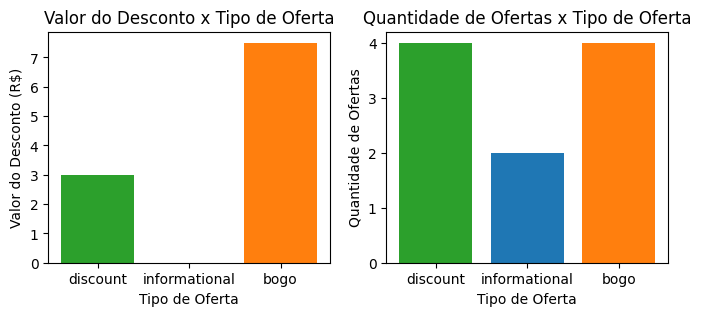

In [7]:
figure, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3))
bar_colors = ['tab:green', 'tab:blue', 'tab:orange']
bar_values1 = df_offers.groupBy("offer_type").agg({"discount_value": "avg"}).collect()
bar_labels = [row["offer_type"] for row in bar_values1]
bar_values1 = [row["avg(discount_value)"] for row in bar_values1]

bar_values2 = df_offers.groupBy("offer_type").agg({"id": "count"}).select("count(id)").collect()
bar_values2 = [row["count(id)"] for row in bar_values2]

plot_bars(axes=ax1, data_values=bar_values1, data_labels=bar_labels, data_colors=bar_colors, title="Valor do Desconto x Tipo de Oferta", x_label="Tipo de Oferta", y_label="Valor do Desconto (R$)")

plot_bars(axes=ax2, data_values=bar_values2, data_labels=bar_labels, data_colors=bar_colors, title="Quantidade de Ofertas x Tipo de Oferta", x_label="Tipo de Oferta", y_label="Quantidade de Ofertas")

plt.show()

Em relação ao formato dos dado, vemos que todas as colunas estão com os tipos de dados esperados.

In [9]:
info_alternative(df_offers)

Number of rows: 10
Number of columns: 6
#	Column		Non-Null Count		Dtype
---	------		--------------		-----
0	channels		10		array<string>
1	discount_value		10		bigint
2	duration		10		double
3	id		10		string
4	min_value		10		bigint
5	offer_type		10		string


Vemos também que:
- Uma oferta pode durar de 3 a 10 dias, com uma duração média de 6 dias.
- O valor mínimo para uma oferta poder ser aplicada, quando ela possui, costuam ser em torno de $R\$ 8,00$. Mas pode chegar até a $R\$ 20,00$.
- Os descontos, quando existentes, costumam variar de $R\$ 2,00$ a $R\$ 10,00$.

In [10]:
df_offers.describe().show()

25/09/27 10:53:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+------------------+--------------------+-----------------+-------------+
|summary|   discount_value|          duration|                  id|        min_value|   offer_type|
+-------+-----------------+------------------+--------------------+-----------------+-------------+
|  count|               10|                10|                  10|               10|           10|
|   mean|              4.2|               6.5|                NULL|              7.7|         NULL|
| stddev|3.583914681524163|2.3213980461973533|                NULL|5.831904586934796|         NULL|
|    min|                0|               3.0|0b1e1539f2cc45b7b...|                0|         bogo|
|    max|               10|              10.0|fafdcd668e3743c1b...|               20|informational|
+-------+-----------------+------------------+--------------------+-----------------+-------------+



### 4.2. Profiles Table

In [11]:
# display(df_profile)
df_profile.show(5)

+---+-----------------+------+--------------------+-------------+
|age|credit_card_limit|gender|                  id|registered_on|
+---+-----------------+------+--------------------+-------------+
|118|             NULL|  NULL|68be06ca386d4c319...|     20170212|
| 55|         112000.0|     F|0610b486422d4921a...|     20170715|
|118|             NULL|  NULL|38fe809add3b4fcf9...|     20180712|
| 75|         100000.0|     F|78afa995795e4d85b...|     20170509|
|118|             NULL|  NULL|a03223e636434f42a...|     20170804|
+---+-----------------+------+--------------------+-------------+
only showing top 5 rows


Com relação à tabela de informações dos usuários (**Profile**), vemos que ela possui valores faltantes para **gênero** e limite do **cartão de crédito**. Talvez o usuário tenha decidido não informar esses dados, caso não sejam obrigatórios.

Com relação aos tipos dos dados, quase todos estão corretos, com exceção do campo **registered_on**, que apesar de originalmente estar como um número inteiro, foi carregado como uma string, mas poderia ser melhor representado como um **datetime**, já que indica a data em que o usuário se registrou na plataforma. Além disso, percebemos que ele está seguindo o formato YYYYMMDD.

In [12]:
info_alternative(df_profile)

Number of rows: 17000
Number of columns: 5
#	Column		Non-Null Count		Dtype
---	------		--------------		-----
0	age		17000		bigint
1	credit_card_limit		14825		double
2	gender		14825		string
3	id		17000		string
4	registered_on		17000		string


Com relação ao gênero, temos 3 categorias, além das amostras marcadas como nulas:
- M: masculino
- F: feminino
- O: outros

Alguns clientes não informaram o gênero (ou houve algum problema na coleta) e eles estão com valores nulos. Como esses casos representam quase 13% da base (2175/17000), resolvemos subsituir os valores nulos pela sigla **"NI" (Não Informado)**, ao invés de deletá-los da base.

O mesmo se aplica para o valor do **limite do cartão de crédito**. Mas nestes casos, subsituimos os valores nulos por zero.

Apesar de termos alguma diversidade de gêneros na base de dados, **a maioria dos clientes registrados na plataforma no período de coleta dos dados são do sexo masculino**, seguidos de pessoas do sexo feminino, não informado (NI) e outros.

Com relação ao poder aquisitivo, apesar de não serem maioria na base, clientes do sexo feminino são as que demonstrarm maior valor médio de limite não cartão de crédito, seguidas de pessoas que se identificam com outros gêneros e pessoas do sexo masculino.

Pessoas que não indicaram o gênero também não indicaram o valor do limite do cartão de crédito. Isso pode indicar que, se estas opções forem opcionais no momento do cadastro, essas pessoas resolveram pular, preenchendo apenas o básico.

In [5]:
df_profile = df_profile.withColumn(
    "gender",
    when(col("gender").isNull(), "NI").otherwise(col("gender"))
)
gender_counts = (
    df_profile.groupBy("gender")
    .agg(count("*").alias("count"))
)

df_profile = df_profile.withColumn(
    "credit_card_limit",
    when(col("credit_card_limit").isNull(), 0).otherwise(col("credit_card_limit"))
)

<Axes: title={'center': 'Valor Médio do Cartão de Crédito x Gênero'}, xlabel='Gênero', ylabel='Valor Médio do Limite (R$)'>

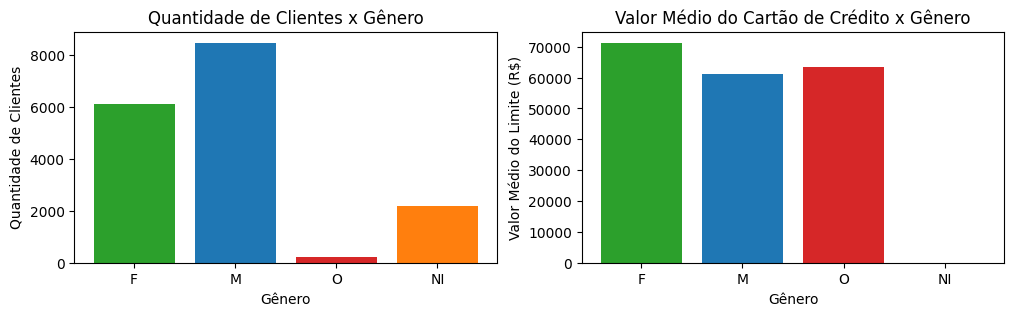

In [9]:
figure, (ax1, ax2) = plt.subplots(1,2, figsize=(12,3))
bar_colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange']

gender_counts = gender_counts.collect()
bar_values1 = [row["count"] for row in gender_counts]
bar_labels = [row["gender"] for row in gender_counts]

bar_values2 = df_profile.groupBy("gender").agg({"credit_card_limit": "avg"}).collect()
bar_values2 = [row["avg(credit_card_limit)"] for row in bar_values2]

plot_bars(axes=ax1, data_values=bar_values1, data_labels=bar_labels, data_colors=bar_colors, title="Quantidade de Clientes x Gênero", x_label="Gênero", y_label="Quantidade de Clientes")

plot_bars(axes=ax2, data_values=bar_values2, data_labels=bar_labels, data_colors=bar_colors, title="Valor Médio do Cartão de Crédito x Gênero", x_label="Gênero", y_label="Valor Médio do Limite (R$)")

Com relação à data em que as pessoas se registraram na plataforma, ao invés de subsituir a coluna original, criamos uma nova coluna com os valores convertidos para o tipo **datetime**, o que facilita alguns tipos de manipulações. Também convertemos a coluna "registered_on" de volta para inteiro. 

Além disso, podemos perceber, conforme o gráfico abaixo, que houve um crescimento de clientes registrados na plataforma ao longo dos anos, o que é um bom sinal de aceitação da plataforma. Apesar disso, o gráfico também mostra uma queda na quantidade de clientes que se registraram em 2018, o que talvez seja explicado pelo fato de os dados terem sido coletados apenas até julho. Então, é possível que esse valor mude ao coletarmos os dados do restante do ano.



In [6]:
df_profile = df_profile.withColumn("registered_on_dt", to_date("registered_on", "yyyyMMdd"))
df_profile = df_profile.withColumn("registered_on", col("registered_on").cast("int"))

df_profile.describe().show()

25/09/27 16:58:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------+--------------------+--------------------+
|summary|               age| credit_card_limit|gender|                  id|       registered_on|
+-------+------------------+------------------+------+--------------------+--------------------+
|  count|             17000|             17000| 17000|               17000|               17000|
|   mean| 62.53141176470588|           57037.0|  NULL|2.565638242424101E31|2.0167034234117646E7|
| stddev|26.738579945767256|29734.044500817927|  NULL|                NULL|  11677.499960793006|
|    min|                18|               0.0|     F|0009655768c64bdeb...|            20130729|
|    max|               118|          120000.0|     O|ffff82501cea40309...|            20180726|
+-------+------------------+------------------+------+--------------------+--------------------+



<Axes: title={'center': 'Quantidade de Clientes Registrados ao Longo dos Anos'}, xlabel='Ano', ylabel='Quantidade de Clientes Registrados'>

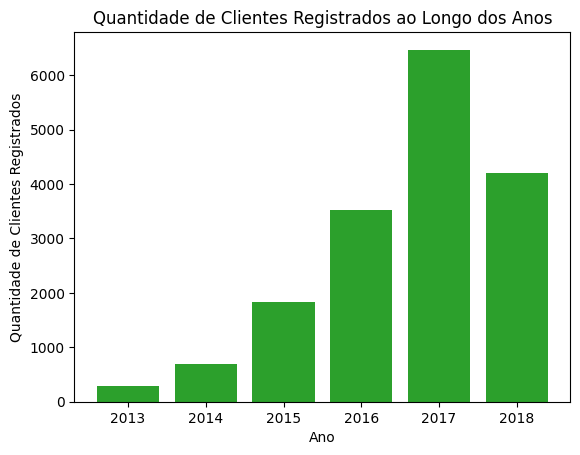

In [11]:
years = (
    df_profile
    .withColumn("year", year(col("registered_on_dt")))
    .groupBy("year")
    .count()
    .orderBy("year")
).toPandas()

fig, ax = plt.subplots(1,1)
plot_bars(axes=ax, data_values=years["count"], data_labels=years["year"], data_colors=['tab:green'], title="Quantidade de Clientes Registrados ao Longo dos Anos", x_label="Ano", y_label="Quantidade de Clientes Registrados")


Também podemos perceber que um número considerável de clientes está com idade maior que 100 anos, ao passo que 75% dos clientes possuem apenas até 73 anos. Isso acaba puxando a média das idades um pouco mais para cima, conforme podemos ver nos gráficos abaixo.

Esses valores possivelmente resultam de algum problema na coleta dos dados ou entrada do usuário, já que o número de pessoas que vivem mais de 100 anos é pequeno em relação ao total da população, mas eles estão representando 13% dos nossos dados. Tendo isso em vista, resolvemos subsituir os valores maiores que 100 anos pela mediana das idades, para tornar os dados um pouco mais coerentes.

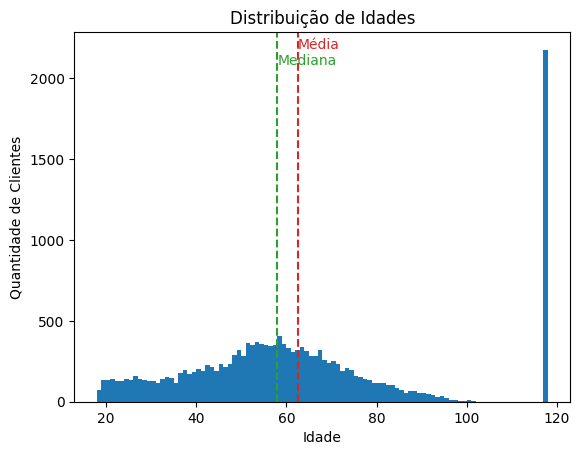

In [7]:
ages = df_profile.select("age").toPandas()["age"]
age_mean = df_profile.select(avg("age")).first()[0]
age_median = df_profile.approxQuantile("age", [0.5], 0.01)[0]

fig, ax = plt.subplots(1,1)
plot_hist(axes=ax, data_values=ages, n_bins=100, title="Distribuição de Idades", x_label="Idade", y_label="Quantidade de Clientes", data_mean=age_mean, data_median=age_median)

plt.show()

In [8]:
df_profile = df_profile.withColumn(
    "age",
    when(col("age") > 100, age_median).otherwise(col("age"))
)

df_profile.describe().show()

+-------+------------------+------------------+------+--------------------+--------------------+
|summary|               age| credit_card_limit|gender|                  id|       registered_on|
+-------+------------------+------------------+------+--------------------+--------------------+
|  count|             17000|             17000| 17000|               17000|               17000|
|   mean| 54.84229411764706|           57037.0|  NULL|2.565638242424101E31|2.0167034234117646E7|
| stddev|16.259018395608656|29734.044500817927|  NULL|                NULL|  11677.499960793006|
|    min|              18.0|               0.0|     F|0009655768c64bdeb...|            20130729|
|    max|             100.0|          120000.0|     O|ffff82501cea40309...|            20180726|
+-------+------------------+------------------+------+--------------------+--------------------+



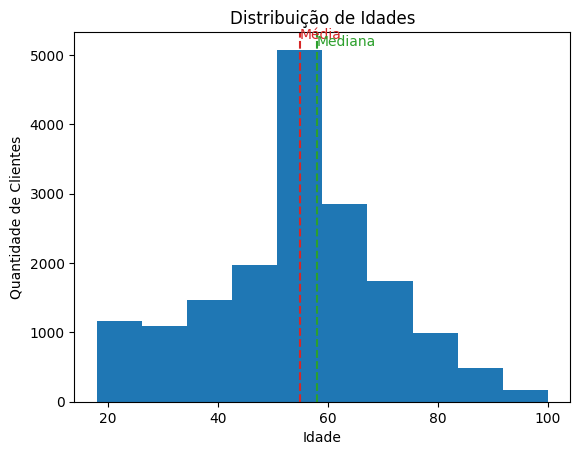

In [14]:
ages = df_profile.select("age").toPandas()["age"]
age_mean = df_profile.select(avg("age")).first()[0]
age_median = df_profile.approxQuantile("age", [0.5], 0.01)[0]

fig, ax = plt.subplots(1,1)
plot_hist(axes=ax, data_values=ages, n_bins=10, title="Distribuição de Idades", x_label="Idade", y_label="Quantidade de Clientes", data_mean=age_mean, data_median=age_median)

plt.show()

### 4.3. Transactions Table

Em relação aos **Dados de Transações**, podemos observar que não há campos com valores NaN e que os tipos de dados estão corretos. 

No entanto, no campo **value**, que possui dicionários como valores, estes apresentam alguns problemas, como chaves muito semelhantes com valores diferentes (por exemplo, "offer id" e "offer_id") e valores NaN em alguns campos (por exemplo, em "amount").

In [21]:
# display(df_transactions)
df_transactions.show(5)

+--------------------+--------------+---------------------+--------------------+
|          account_id|         event|time_since_test_start|               value|
+--------------------+--------------+---------------------+--------------------+
|78afa995795e4d85b...|offer received|                  0.0|{NULL, 9b98b8c7a3...|
|a03223e636434f42a...|offer received|                  0.0|{NULL, 0b1e1539f2...|
|e2127556f4f64592b...|offer received|                  0.0|{NULL, 2906b810c7...|
|8ec6ce2a7e7949b1b...|offer received|                  0.0|{NULL, fafdcd668e...|
|68617ca6246f4fbc8...|offer received|                  0.0|{NULL, 4d5c57ea9a...|
+--------------------+--------------+---------------------+--------------------+
only showing top 5 rows


In [23]:
df_transactions.select("value").first()

Row(value=Row(amount=None, offer id='9b98b8c7a33c4b65b9aebfe6a799e6d9', offer_id=None, reward=None))

In [24]:
info_alternative(df_transactions)

Number of rows: 306534
Number of columns: 4
#	Column		Non-Null Count		Dtype
---	------		--------------		-----


0	account_id		306534		string


1	event		306534		string


2	time_since_test_start		306534		double


3	value		306534		struct<amount:double,offer id:string,offer_id:string,reward:double>


Com o objetivo de facilitar a manipulação dos dados de transação, extraímos os dicionários do campo **value** e inserimos seus valores como novas colunas do dataframe de transações.

In [9]:
df_transactions = df_transactions.select("*", col("value.*")).drop("value")

# display(df_transactions)
df_transactions.show(5)

+--------------------+--------------+---------------------+------+--------------------+--------+------+
|          account_id|         event|time_since_test_start|amount|            offer id|offer_id|reward|
+--------------------+--------------+---------------------+------+--------------------+--------+------+
|78afa995795e4d85b...|offer received|                  0.0|  NULL|9b98b8c7a33c4b65b...|    NULL|  NULL|
|a03223e636434f42a...|offer received|                  0.0|  NULL|0b1e1539f2cc45b7b...|    NULL|  NULL|
|e2127556f4f64592b...|offer received|                  0.0|  NULL|2906b810c7d441179...|    NULL|  NULL|
|8ec6ce2a7e7949b1b...|offer received|                  0.0|  NULL|fafdcd668e3743c1b...|    NULL|  NULL|
|68617ca6246f4fbc8...|offer received|                  0.0|  NULL|4d5c57ea9a6940dd8...|    NULL|  NULL|
+--------------------+--------------+---------------------+------+--------------------+--------+------+
only showing top 5 rows


Como podemos ver, **"offer id"** e **"offer_id"** parecem ter a mesma finalidade, mas são escritos de forma ligeiramente diferente e têm valores diferentes para a maioria de suas entradas. Além disso, quando um deles é NaN, o outro tem valores não Nan.

In [10]:
not_nan_offers_underline = df_transactions.filter(col("offer_id").isNotNull()).select("offer id", "offer_id")
not_nan_offers_space = df_transactions.filter(col("offer id").isNotNull()).select("offer id", "offer_id")

print(f"O campo 'offer id' possui {not_nan_offers_space.count()} valores não nulos e o campo 'offer_id' possui {not_nan_offers_underline.count()} valores não nulos.")

O campo 'offer id' possui 134002 valores não nulos e o campo 'offer_id' possui 33579 valores não nulos.


In [29]:
info_alternative(not_nan_offers_underline)

Number of rows: 33579
Number of columns: 2
#	Column		Non-Null Count		Dtype
---	------		--------------		-----


0	offer id		0		string


1	offer_id		33579		string


In [30]:
info_alternative(not_nan_offers_space)

Number of rows: 134002
Number of columns: 2
#	Column		Non-Null Count		Dtype
---	------		--------------		-----


0	offer id		134002		string


1	offer_id		0		string


Pensando nisso, resolvemos uni-los em um único campo, chamado **offer_id**, preenchendo todos os valores NaN de **offer_id** com os valores não nulos de **offer id** na posição respectiva. Além disso, removemos a coluna **offer id**, pois não é mais necessária.

In [11]:
df_transactions = df_transactions.withColumn("offer_id", coalesce(col("offer_id"), col("offer id"))).drop("offer id")
df_transactions.show(5)

+--------------------+--------------+---------------------+------+--------------------+------+
|          account_id|         event|time_since_test_start|amount|            offer_id|reward|
+--------------------+--------------+---------------------+------+--------------------+------+
|78afa995795e4d85b...|offer received|                  0.0|  NULL|9b98b8c7a33c4b65b...|  NULL|
|a03223e636434f42a...|offer received|                  0.0|  NULL|0b1e1539f2cc45b7b...|  NULL|
|e2127556f4f64592b...|offer received|                  0.0|  NULL|2906b810c7d441179...|  NULL|
|8ec6ce2a7e7949b1b...|offer received|                  0.0|  NULL|fafdcd668e3743c1b...|  NULL|
|68617ca6246f4fbc8...|offer received|                  0.0|  NULL|4d5c57ea9a6940dd8...|  NULL|
+--------------------+--------------+---------------------+------+--------------------+------+
only showing top 5 rows


In [32]:
info_alternative(df_transactions)

Number of rows: 306534
Number of columns: 6
#	Column		Non-Null Count		Dtype
---	------		--------------		-----


0	account_id		306534		string


1	event		306534		string


2	time_since_test_start		306534		double


3	amount		138953		double


4	offer_id		167581		string


5	reward		33579		double


Com relação aos tipos de eventos registrados nos dados de **Transações**, temos 4 tipos:
- **transaction**: diz respeito a transações realizadas pelo usuário na plataforma, como a compra de um produto.
- **offer received**: refere-se a quando um usuário recebe uma oferta.
- **offer viewed**: refere-se a quando o usuário viu a oferta recebida.
- **offer completed**: refere-se a quando o usuário utiliza a oferta vista.

De acordo com o gráfico de distribuição da quantidade de eventos por tipo, vemos que **compras (transaction)** são o tipo mais comum registrado na base. 

Além disso, o número de ofertas decresce conforme avançamos nas etapas de **receber**, **ver** e **usar/completar**, com apenas **75,7% das ofertas recebidas sendo vistas e apenas 58,2% das ofertas vistas sendo utilizadas**.

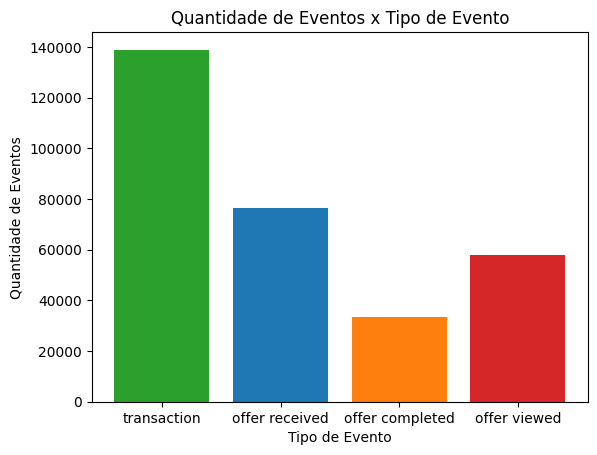

In [12]:
event_counts = (
    df_transactions.groupBy("event")
    .agg(count("*").alias("count"))
)

event_counts = event_counts.collect()
bar_values = [row["count"] for row in event_counts]
bar_labels = [row["event"] for row in event_counts]
bar_colors = ["tab:green", "tab:blue", "tab:orange", "tab:red"]

fig, ax = plt.subplots(1,1)
plot_bars(axes=ax, data_values=bar_values, data_labels=bar_labels, title="Quantidade de Eventos x Tipo de Evento", x_label="Tipo de Evento", y_label="Quantidade de Eventos", data_colors=bar_colors)

plt.show()

In [13]:
events = [row["event"] for row in event_counts]
counts = [row["count"] for row in event_counts]
index_received, index_viewed, index_completed = events.index("offer received"), events.index("offer viewed"), events.index("offer completed")

print(f"Porcentagem das ofertas recebidas que são vistas: {100*(counts[index_viewed]/counts[index_received])}%")
print(f"Porcentagem das ofertas vistas que são completadas: {100*(counts[index_completed]/counts[index_viewed])}%")

Porcentagem das ofertas recebidas que são vistas: 75.67812053436815%
Porcentagem das ofertas vistas que são completadas: 58.17063663923776%


Na base de dados, temos valores das ofertas apenas para aquelas que foram completadas, mas temos valores para todos os eventos do tipo transaction.

Também, conforme podemos observar nos gráficos abaixo, as ofertas com recompensas de até 5 reais são as que mais frequentemente os usuários utilizam. Um possível fator poderia ser as ofertas de 10 reais exigirem um valor mínimo maior, porém, conforme vemos na correlação calculada (~0.5), as variáveis **min_value** e **discount_value** possuem uma correlação moderada, significando que nem sempre esse aumento é o caso. 

Além disso, a maior parte das compras na plataforma possuem valores até 10 reais, com algumas poucas passando de 30 reais, o que pode indicar compras com produtos mais baratos ou com poucos produtos.

In [35]:
df_transactions.describe().show()

+-------+--------------------+---------------+---------------------+------------------+--------------------+------------------+
|summary|          account_id|          event|time_since_test_start|            amount|            offer_id|            reward|
+-------+--------------------+---------------+---------------------+------------------+--------------------+------------------+
|  count|              306534|         306534|               306534|            138953|              167581|             33579|
|   mean|2.565638242424101E31|           NULL|   15.265955815668082| 12.77735615639814|                NULL| 4.904136513892611|
| stddev|                 0.0|           NULL|    8.346929730115084|30.250528632017126|                NULL|2.8866468823372804|
|    min|0009655768c64bdeb...|offer completed|                  0.0|              0.05|0b1e1539f2cc45b7b...|               2.0|
|    max|ffff82501cea40309...|    transaction|                29.75|           1062.28|fafdcd668e3743c1b

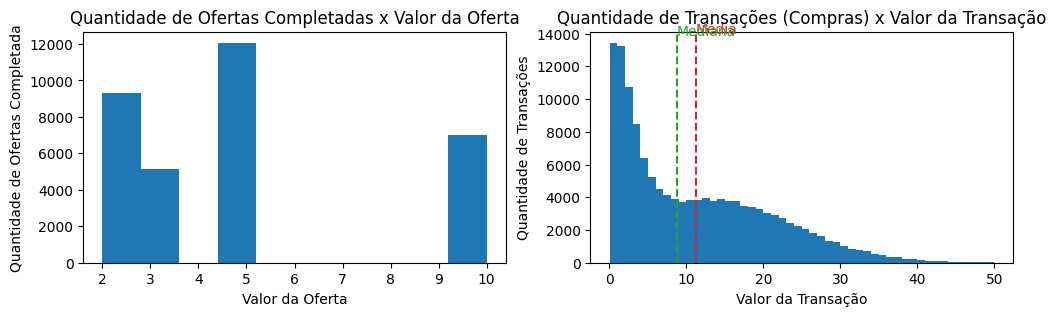

In [14]:
event_offers_completed = df_transactions.filter(col("event") == "offer completed")
event_transactions = df_transactions.filter((col("event") == "transaction") & (col("amount") < 50))

rewards = [row["reward"] for row in event_offers_completed.select("reward").collect()]

amounts = [row["amount"] for row in event_transactions.select("amount").collect()]
amounts_mean = np.mean(amounts)
amounts_median = np.median(amounts)


figure, (ax1, ax2) = plt.subplots(1,2, figsize=(12,3))

plot_hist(axes=ax1, data_values=rewards, title="Quantidade de Ofertas Completadas x Valor da Oferta", x_label="Valor da Oferta", y_label="Quantidade de Ofertas Completada", n_bins=10)
plot_hist(axes=ax2, data_values=amounts, title="Quantidade de Transações (Compras) x Valor da Transação", x_label="Valor da Transação", y_label="Quantidade de Transações", data_mean=amounts_mean, data_median=amounts_median, n_bins=50)

plt.show()

In [21]:
corr_min_value_discount = df_offers.select(corr("min_value", "discount_value").alias("correlation")).first()["correlation"]
print("Correlação entre valor mínimo e valor do desconto:", corr_min_value_discount)

Correlação entre valor mínimo e valor do desconto: 0.465686367223852


## Preparing Data for Training and Testing

Vamos criar uma matriz de fatorização, que estabelece uma relação entre clientes e ofertas. A força dessa relação vai depender do tipo de evento. Se o cliente apenas recebeu a oferta, a força é 1. Se o cliente visualizou a oferta, a força é 3. E se o cliente usou a oferta, a força é 5. Ao final, a força vai ser a média das forças do cliente com aquela oferta.

In [15]:
df_transactions_offers = df_transactions.filter(col("event") != "transaction")
info_alternative(df_transactions_offers)

type_event_map = {"offer received": 1, "offer viewed": 3, "offer completed": 5}
df_transactions_offers = create_id_int_column(data=df_transactions_offers, column_map=type_event_map, original_column_name="event", new_column_name="event_int")

fact_mat_client_offer  = (
    df_transactions_offers
    .groupBy("account_id", "offer_id")
    .agg(avg("event_int").alias("event_levels"))
)

Number of rows: 167581
Number of columns: 6
#	Column		Non-Null Count		Dtype
---	------		--------------		-----


0	account_id		167581		string


1	event		167581		string


2	time_since_test_start		167581		double


3	amount		0		double


4	offer_id		167581		string


5	reward		33579		double


In [16]:
fact_mat_client_offer.show(5)

+--------------------+--------------------+------------------+
|          account_id|            offer_id|      event_levels|
+--------------------+--------------------+------------------+
|0861b9ca31b741bb8...|f19421c1d4aa40978...|               3.0|
|0485b8cb0bfc4d938...|2906b810c7d441179...|               1.0|
|e0f1ca131f4b40a7a...|2298d6c36e964ae4a...|               2.5|
|4ecbfa77f6f84e779...|3f207df678b143eea...|1.6666666666666667|
|523e2d85f3d94eefb...|4d5c57ea9a6940dd8...|               3.0|
+--------------------+--------------------+------------------+
only showing top 5 rows


In [ ]:
unique_account_ids =  fact_mat_client_offer.select("account_id").distinct().rdd.flatMap(lambda x: x).collect()
account_id_map = {val: idx for idx, val in enumerate(unique_account_ids)}

unique_offer_ids =  fact_mat_client_offer.select("offer_id").distinct().rdd.flatMap(lambda x: x).collect()
offer_id_map = {val: idx for idx, val in enumerate(unique_offer_ids)}

fact_mat_client_offer = create_id_int_column(data=fact_mat_client_offer, column_map=account_id_map, original_column_name="account_id", new_column_name="account_id_int")
fact_mat_client_offer = create_id_int_column(data=fact_mat_client_offer, column_map=offer_id_map, original_column_name="offer_id", new_column_name="offer_id_int")

In [19]:
fact_mat_client_offer.show(5)

+--------------------+--------------------+------------------+--------------+------------+
|          account_id|            offer_id|      event_levels|account_id_int|offer_id_int|
+--------------------+--------------------+------------------+--------------+------------+
|0861b9ca31b741bb8...|f19421c1d4aa40978...|               3.0|         11743|           3|
|0485b8cb0bfc4d938...|2906b810c7d441179...|               1.0|          7223|           8|
|e0f1ca131f4b40a7a...|2298d6c36e964ae4a...|               2.5|          8015|           7|
|4ecbfa77f6f84e779...|3f207df678b143eea...|1.6666666666666667|          5998|           9|
|523e2d85f3d94eefb...|4d5c57ea9a6940dd8...|               3.0|           605|           1|
+--------------------+--------------------+------------------+--------------+------------+
only showing top 5 rows


In [20]:
(training, test) = fact_mat_client_offer.randomSplit([0.8, 0.2])
training.count(), test.count()

(50712, 12576)

In [22]:
als_model = ALS(
    userCol="account_id_int",
    itemCol="offer_id_int",
    ratingCol="event_levels",
    coldStartStrategy="drop",
    nonnegative=True
)

In [23]:
param_grid = ParamGridBuilder()\
    .addGrid(als_model.rank, [12,14])\
    .addGrid(als_model.maxIter, [18,20])\
    .addGrid(als_model.regParam, [.17,.19])\
    .build()

In [24]:
## Não quero predizer os levels, quero predizer a oferta. 
evaluator = RegressionEvaluator(metricName="rmse", labelCol="event_levels", predictionCol="prediction")

In [25]:
tvs = TrainValidationSplit(estimator=als_model, estimatorParamMaps=param_grid, evaluator=evaluator)

In [28]:
training.cache()

DataFrame[account_id: string, offer_id: string, event_levels: double, account_id_int: int, offer_id_int: int]

In [27]:
training.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- event_levels: double (nullable = true)
 |-- account_id_int: integer (nullable = false)
 |-- offer_id_int: integer (nullable = false)



In [29]:
model = tvs.fit(training)

25/09/27 17:08:20 WARN CacheManager: Asked to cache already cached data.
25/09/27 17:08:20 WARN CacheManager: Asked to cache already cached data.
25/09/27 17:08:21 WARN DAGScheduler: Broadcasting large task binary with size 1001.3 KiB
25/09/27 17:08:21 WARN DAGScheduler: Broadcasting large task binary with size 1002.9 KiB
25/09/27 17:08:22 WARN DAGScheduler: Broadcasting large task binary with size 1004.2 KiB
25/09/27 17:08:22 WARN DAGScheduler: Broadcasting large task binary with size 1003.1 KiB
25/09/27 17:08:22 WARN DAGScheduler: Broadcasting large task binary with size 1004.5 KiB
25/09/27 17:08:23 WARN DAGScheduler: Broadcasting large task binary with size 1005.3 KiB
25/09/27 17:08:23 WARN DAGScheduler: Broadcasting large task binary with size 1008.6 KiB
25/09/27 17:08:23 WARN DAGScheduler: Broadcasting large task binary with size 1010.2 KiB
25/09/27 17:08:23 WARN DAGScheduler: Broadcasting large task binary with size 1011.7 KiB
25/09/27 17:08:23 WARN DAGScheduler: Broadcasting lar

In [30]:
best_model = model.bestModel
best_model

ALSModel: uid=ALS_c4e5be9c9b40, rank=14

In [31]:
predictions = best_model.transform(test)

In [33]:
predictions.show(5)

25/09/27 17:10:44 WARN DAGScheduler: Broadcasting large task binary with size 1068.3 KiB
25/09/27 17:10:44 WARN DAGScheduler: Broadcasting large task binary with size 1066.8 KiB
25/09/27 17:10:46 WARN DAGScheduler: Broadcasting large task binary with size 1299.4 KiB


+--------------------+--------------------+------------+--------------+------------+----------+
|          account_id|            offer_id|event_levels|account_id_int|offer_id_int|prediction|
+--------------------+--------------------+------------+--------------+------------+----------+
|0011e0d4e6b944f99...|3f207df678b143eea...|         2.0|          7327|           9|  1.693008|
|003d66b6608740288...|5a8bc65990b245e5a...|         2.0|         11137|           6| 1.9093496|
|004c5799adbf42868...|ae264e3637204a6fb...|         3.0|          3044|           5|  2.746664|
|005500a7188546ff8...|2906b810c7d441179...|         1.0|          2571|           8| 2.0293503|
|005500a7188546ff8...|9b98b8c7a33c4b65b...|         3.0|          2571|           2| 2.5798802|
+--------------------+--------------------+------------+--------------+------------+----------+
only showing top 5 rows


In [34]:
rmse = evaluator.evaluate(predictions)
rmse

25/09/27 17:11:29 WARN DAGScheduler: Broadcasting large task binary with size 1068.3 KiB
25/09/27 17:11:29 WARN DAGScheduler: Broadcasting large task binary with size 1066.8 KiB
25/09/27 17:11:32 WARN DAGScheduler: Broadcasting large task binary with size 1301.6 KiB


0.4367290753014333

In [36]:
user_recs = best_model.recommendForAllUsers(3)

In [39]:
user_recs.first()

25/09/27 17:17:58 WARN DAGScheduler: Broadcasting large task binary with size 1116.7 KiB
25/09/27 17:17:59 WARN DAGScheduler: Broadcasting large task binary with size 1112.6 KiB


Row(account_id_int=1, recommendations=[Row(offer_id_int=4, rating=2.073538303375244), Row(offer_id_int=7, rating=2.035352945327759), Row(offer_id_int=8, rating=2.0225791931152344)])

In [ ]:
list(filter(lambda key: account_id_map[key] == 1, account_id_map))


['9da3f2339b244229a8337572e982b189']

In [42]:
list(filter(lambda key: offer_id_map[key] == 4, offer_id_map))

['fafdcd668e3743c1bb461111dcafc2a4']

In [40]:
fact_mat_client_offer.describe().show()

+-------+--------------------+--------------------+------------------+-----------------+------------------+
|summary|          account_id|            offer_id|      event_levels|   account_id_int|      offer_id_int|
+-------+--------------------+--------------------+------------------+-----------------+------------------+
|  count|               63288|               63288|             63288|            63288|             63288|
|   mean|2.565638242424101E31|                NULL|2.2835993124910443| 8491.72200101125| 4.494975350777398|
| stddev|                 0.0|                NULL|0.7120599822000341|4903.009137261942|2.8734546359825313|
|    min|0009655768c64bdeb...|0b1e1539f2cc45b7b...|               1.0|                0|                 0|
|    max|ffff82501cea40309...|fafdcd668e3743c1b...|               3.0|            16993|                 9|
+-------+--------------------+--------------------+------------------+-----------------+------------------+



25/09/27 17:19:17 WARN DAGScheduler: Broadcasting large task binary with size 1029.7 KiB


In [45]:
df_transactions_offers.select("*").where(col("account_id") == "9da3f2339b244229a8337572e982b189").show()

+--------------------+---------------+---------------------+------+--------------------+------+---------+
|          account_id|          event|time_since_test_start|amount|            offer_id|reward|event_int|
+--------------------+---------------+---------------------+------+--------------------+------+---------+
|9da3f2339b244229a...| offer received|                  0.0|  NULL|4d5c57ea9a6940dd8...|  NULL|        1|
|9da3f2339b244229a...|   offer viewed|                 4.25|  NULL|4d5c57ea9a6940dd8...|  NULL|        3|
|9da3f2339b244229a...| offer received|                  7.0|  NULL|ae264e3637204a6fb...|  NULL|        1|
|9da3f2339b244229a...|   offer viewed|                  7.0|  NULL|ae264e3637204a6fb...|  NULL|        3|
|9da3f2339b244229a...| offer received|                 14.0|  NULL|0b1e1539f2cc45b7b...|  NULL|        1|
|9da3f2339b244229a...| offer received|                 17.0|  NULL|2906b810c7d441179...|  NULL|        1|
|9da3f2339b244229a...|offer completed|        